In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import asyncio
from rtlsdr import RtlSdr
import ugradio
from scipy.ndimage import median_filter, uniform_filter1d

to do: chapters 8, 9, and 10:\
[x] - find speed of light in the cable - 0.68$\pm$0.04c\
[x] - find power loss per m in cable\
[x] - find length of cable from 541 to roof\
[x] - find power lost in cable

[x] - find power lost in homebrew amplifier and bandpass

[x] - find bits to voltage conversion - is it linear?
[x] - get more data points

[x] - find total power loss -> gain from SDR to receiver

In [50]:
data_sg = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_signal_test.npz")
data_scal = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_blackbody_0302 (1).npz")
data_scold = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_zenith_0302 (1).npz")
data_son = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_cyg_x_on.npz") 
data_soff = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_cyg_x_off_2MHz.npz")

bits_to_volts = 1 #8.11968986e-06
antenna_efficiency = 0.65 #placeholder for now
print("bits to volts at 45dB gain: 8.11968986e-06 +- 3.02632578e-06 V/Bit")

bits to volts at 45dB gain: 8.11968986e-06 +- 3.02632578e-06 V/Bit


In [51]:
print(data_son.files)

['samples', 'jd_before', 'jd_after', 'utc_before', 'utc_after', 'utc_unix_before', 'utc_unix_after', 'local_before', 'local_after', 'lst_before', 'lst_after', 'coords_altaz', 'coords_nch', 'center_freq', 'sample_rate']


In [52]:
def power_spectrum_average(data, method='mean'):
    """
    Calculates the averaged power spectrum of multiple complex I/Q signals.
    
    Parameters:
    samples (np.ndarray): A 3D array of shape (M, N, 2) 
                      where M = number of observations, N = samples per observation.
    fs (float): The sampling rate in Hz.
    method (str): 'mean' or 'median' to combine the spectra.
    
    Returns:
    freqs_shifted (np.ndarray): The centered frequency axis.
    averaged_power (np.ndarray): The averaged power spectrum of size N.
    """
    # Get the number of observations (M) and samples per observation (N)
    M, N, _ = data["samples"].shape
    
    # 1. Convert the (M, N, 2) array into a 2D complex array of shape (M, N)
    # samples[:, :, 0] is the Real (I) and samples[:, :, 1] is the Imaginary (Q)
    complex_signal = (data["samples"][:, :, 0] * bits_to_volts / antenna_efficiency) + 1j * (data["samples"][:, :, 1] * bits_to_volts / antenna_efficiency)
    
    # 2. Compute the FFT along the N dimension (axis=1) for all M arrays simultaneously
    fft_result = np.fft.fft(complex_signal, axis=1)
    
    # 3. Shift the zero-frequency (DC) component to the center of the array
    fft_shifted = np.fft.fftshift(fft_result, axes=1)
    
    # 4. Calculate the power spectrum for all M arrays
    power = np.abs(fft_shifted)**2 / N
    
    # 5. Average the power spectra across the M observations (axis=0)
    if method == 'median':
        averaged_power = np.median(power, axis=0)
    else:
        averaged_power = np.mean(power, axis=0)
        
    # 6. Generate the frequency axis and shift it
    freqs = np.fft.fftfreq(N, d=1/data["sample_rate"]) + data["center_freq"]
    freqs_shifted = np.fft.fftshift(freqs)
    
    return freqs_shifted, averaged_power

def robust_clean_and_smooth(power_spectrum, window_size=31, threshold_sigma=3.0, smooth_channels=5):
    """
    Cleans RFI spikes using a rolling Median Absolute Deviation (MAD) and smoothes the result.
    This safely preserves broad physical signals (like the HI bump) while removing narrow spikes.
    
    Parameters:
    power_spectrum (np.ndarray): 1D array of the power spectrum.
    window_size (int): Must be wider than the RFI spike, but narrower than the HI bump.
    threshold_sigma (float): Number of standard deviations to trigger outlier detection.
    smooth_channels (int): Window size for the final moving average smoothing.
    """
    
    # 1. Calculate the rolling median
    # This creates a baseline that tracks the HI bump but cuts straight through the narrow spike
    rolling_median = median_filter(power_spectrum, size=window_size)
    
    # 2. Calculate the local noise floor using Median Absolute Deviation (MAD)
    # MAD is highly resistant to outliers compared to standard deviation
    abs_diff = np.abs(power_spectrum - rolling_median)
    rolling_mad = median_filter(abs_diff, size=window_size)
    
    # Scale MAD to an equivalent standard deviation for a normal distribution
    rolling_std = rolling_mad * 1.4826
    
    # 3. Create a mask of outliers
    # We add a tiny epsilon to avoid division by zero in perfectly flat regions
    epsilon = 1e-10
    outlier_mask = abs_diff > (threshold_sigma * rolling_std + epsilon)
    
    # 4. Replace the bad spikes with the safe rolling median
    cleaned_power = np.copy(power_spectrum)
    cleaned_power[outlier_mask] = rolling_median[outlier_mask]
    
    # 5. Smooth the cleaned data
    smoothed_power = uniform_filter1d(cleaned_power, size=smooth_channels)
    
    return smoothed_power, outlier_mask, rolling_median

def find_hi_peak(freqs, cleaned_spectrum):
    """
    Identifies the maximum value of the smoothed HI line and returns its frequency.
    
    Parameters:
    freqs (np.ndarray): 1D array of the frequency axis.
    cleaned_spectrum (np.ndarray): 1D array of the smoothed power spectrum (or baseline).
    
    Returns:
    peak_freq (float): The frequency where the HI line peaks.
    peak_power (float): The power magnitude at the peak.
    peak_idx (int): The array index of the peak.
    """
    # Find the index of the absolute maximum value in the spectrum
    peak_idx = np.argmax(cleaned_spectrum)
    
    # Extract the corresponding frequency and power using that index
    peak_freq = freqs[peak_idx]
    peak_power = cleaned_spectrum[peak_idx]
    
    return peak_freq, peak_power, peak_idx

In [53]:
freq_son, power_son = power_spectrum_average(data_son, method = "median")
freq_soff, power_soff = power_spectrum_average(data_soff, method = "median") # change to data_soff
freq_scal, power_scal = power_spectrum_average(data_scal, method = "median") # change to data_soff
freq_scold, power_scold = power_spectrum_average(data_scold, method = "median") # change to data_soff

power_son_smoothed, outliers_son, rolling_son = robust_clean_and_smooth(power_son)
power_soff_smoothed, outliers_soff, rolling_soff = robust_clean_and_smooth(power_soff)
power_scal_smoothed, outliers_scal, rolling_scal = robust_clean_and_smooth(power_scal)
power_scold_smoothed, outliers_scold, rolling_scold = robust_clean_and_smooth(power_scold)

r = power_son / power_soff
r_smooth = power_son_smoothed / power_soff_smoothed
r_rolling = rolling_son / rolling_soff

freq_peak, power_peak, idx_peak = find_hi_peak(freq_son, r_rolling)

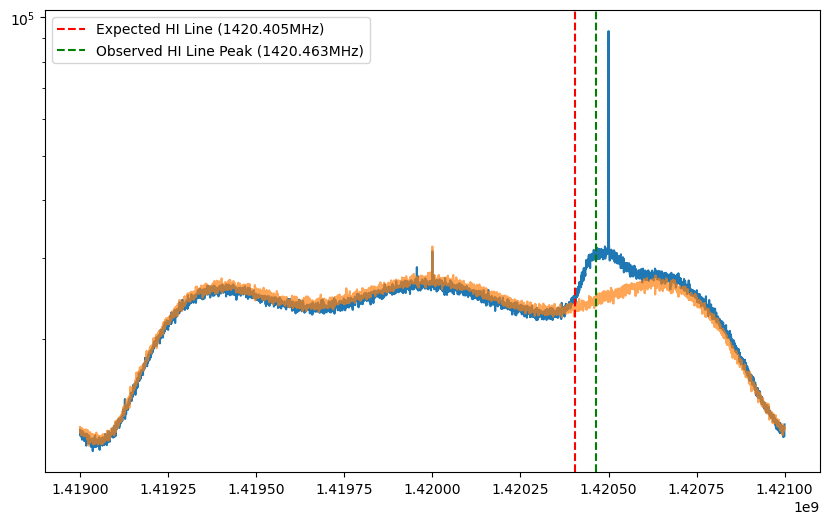

In [54]:
plt.figure(figsize = (10, 6))

plt.plot(freq_son, power_son)
plt.plot(freq_soff, power_soff, alpha = 0.7)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.7}MHz)")
plt.legend()
plt.yscale("log")

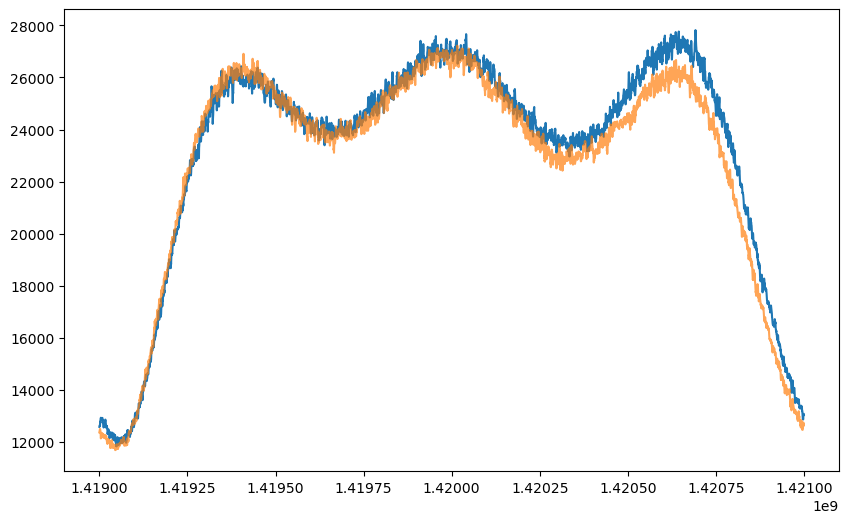

In [55]:
plt.figure(figsize = (10, 6))

plt.plot(freq_son, power_scal_smoothed)
plt.plot(freq_soff, power_scold_smoothed, alpha = 0.7)
# plt.yscale("log")


In [57]:
print(data_scal["samples"], data_scold["samples"])

[[[  -1    0]
  [  -1   -1]
  [   0   -1]
  ...
  [-128   46]
  [  42  127]
  [  24  -97]]

 [[  39   25]
  [ 127  -92]
  [-128 -114]
  ...
  [   2  122]
  [ -60  127]
  [  64  -34]]

 [[-115  103]
  [ -52  120]
  [  39  -60]
  ...
  [ 127  108]
  [  56 -128]
  [-111   51]]

 ...

 [[-128  -37]
  [ -61 -128]
  [ 127  -44]
  ...
  [-128 -128]
  [  72  -48]
  [ 127   31]]

 [[  36  100]
  [ -52  -97]
  [  91   69]
  ...
  [   6  -40]
  [  91  -69]
  [ -20  127]]

 [[  -4   98]
  [ 127  127]
  [-128    5]
  ...
  [ -94   90]
  [  66  -37]
  [ 110  -43]]] [[[ -20   20]
  [ -19   26]
  [  -1  -34]
  ...
  [ -94 -128]
  [ 127   -9]
  [  54  127]]

 [[  -1 -119]
  [ -65   97]
  [ 127  -32]
  ...
  [ -90  -45]
  [ -69  120]
  [ -49   92]]

 [[  34  -15]
  [ -60   70]
  [  20 -106]
  ...
  [   5  -56]
  [  18 -122]
  [ 101  121]]

 ...

 [[ -90 -119]
  [  76 -120]
  [-105   22]
  ...
  [ -68 -111]
  [  13   96]
  [ -13  -49]]

 [[ -20  127]
  [  39  -34]
  [ 127  -21]
  ...
  [  55 -128]
  [ -9

[False False False ... False False False]


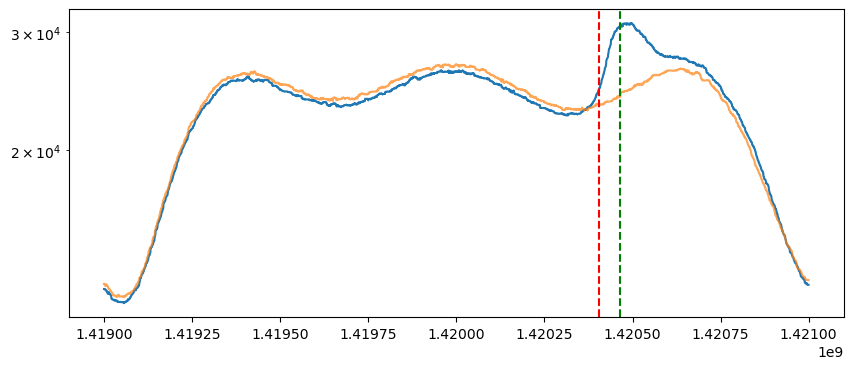

In [8]:
print(outliers_son)
plt.figure(figsize = (10, 4))
plt.plot(freq_son, rolling_son)
plt.plot(freq_soff, rolling_soff, alpha = 0.7)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.yscale("log")
# plt.xlim(1.42045e9, 1.42060e9)

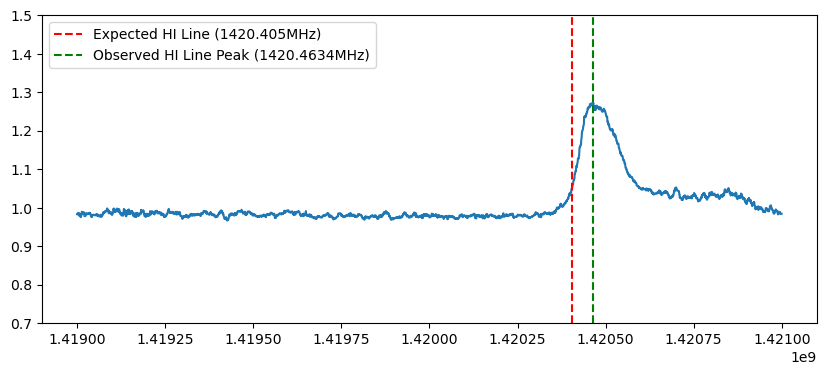

In [9]:
r = power_son / power_soff
r_smooth = power_son_smoothed / power_soff_smoothed
r_rolling = rolling_son / rolling_soff

plt.figure(figsize=(10, 4))
# plt.plot(freq_son, r)
# plt.plot(freq_son, r_smooth)
plt.plot(freq_son, r_rolling)
plt.ylim(0.7, 1.5)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.legend()
plt.show()

In [10]:
def gain(s_cal, s_cold, T_rx = 300, T_hot = 300, T_cold = 10):
    T_sys_cal = T_rx + T_hot
    T_sys_cold = T_rx + T_cold

    sum_cal = sum(s_cal)
    sum_diff = sum(s_cal - s_cold)

    G = ((T_sys_cal - T_sys_cold) * sum_cal) / sum_diff
    return 10 * np.log10(G)

G = gain(power_scal, power_scold)

T_son = r_rolling * G

print(G)

33.495657331803145


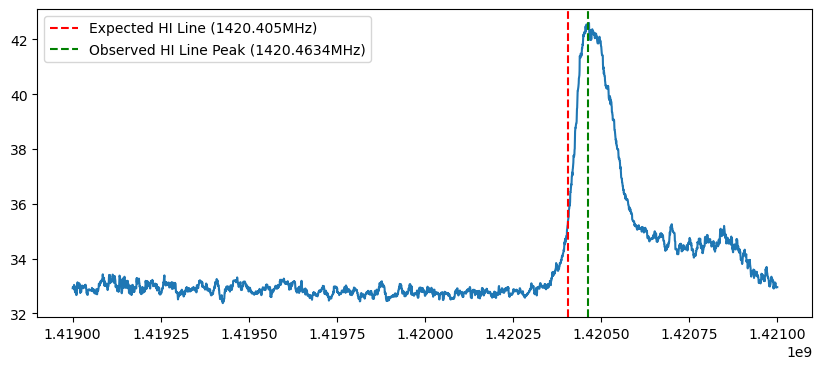

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(freq_son, T_son)
# plt.ylim(0.7, 1.5)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.legend()
plt.show()

In [12]:
def velocity(nu, nu_0=1420.406e6):
    delta_nu = nu - nu_0
    c = 299792458
    v = - (c * delta_nu) / nu
    return v

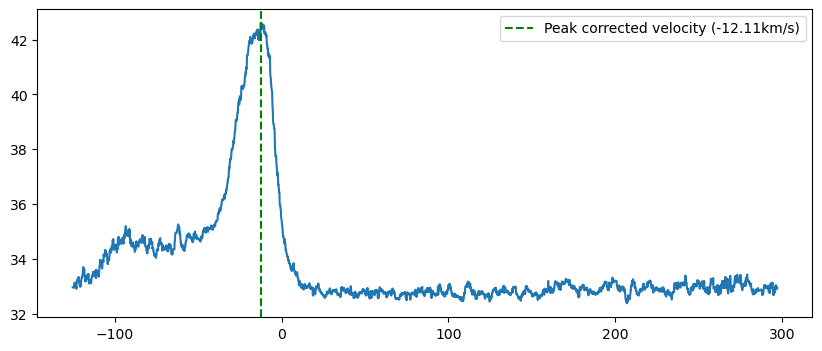

In [13]:
velocity_profile = velocity(freq_son)

v_peak, v_max, v_idx = find_hi_peak(velocity_profile, T_son)

plt.figure(figsize = (10, 4))
plt.plot(velocity_profile / 1000, T_son)
plt.axvline(v_peak / 1000, color = "green", linestyle = "--", label=f"Peak corrected velocity ({v_peak/1000:.6}km/s)")
plt.legend()

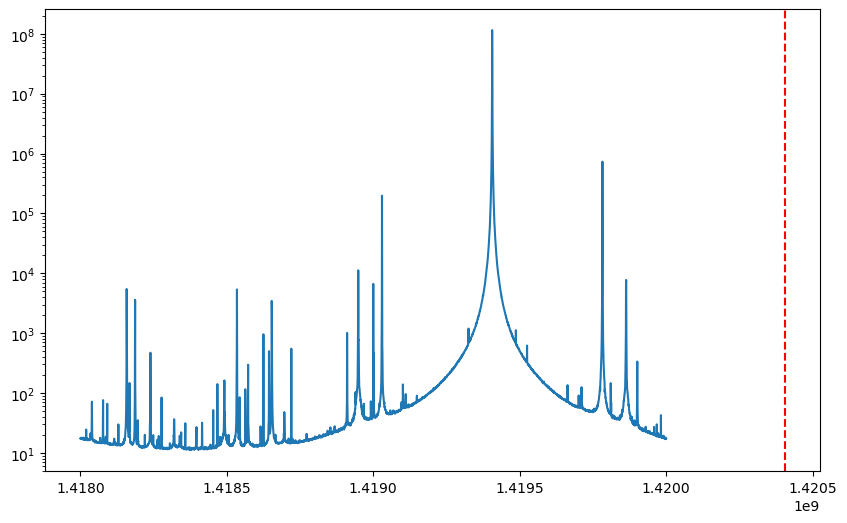

In [14]:
sg_freq, sg_power = power_spectrum_average(data_sg, method='mean')

plt.figure(figsize = (10, 6))

plt.axvline(1420.405e6, color = "red", linestyle = "--")
plt.semilogy(sg_freq, sg_power)

### reference frame

In [15]:
print(data_son.files)

['samples', 'jd_before', 'jd_after', 'utc_before', 'utc_after', 'utc_unix_before', 'utc_unix_after', 'local_before', 'local_after', 'lst_before', 'lst_after', 'coords_altaz', 'coords_nch', 'center_freq', 'sample_rate']


In [16]:
print(data_son["coords_nch"])

[  37.8732 -237.7427]


In [17]:
def get_rotation_matrices(data):
    """
    Generates a dictionary of 3x3 rotation matrices for coordinate transformations.
    
    Parameters:
    lat_deg (float): Observer's terrestrial latitude in degrees.
    lst_hours (float): Local Sidereal Time in decimal hours.
    
    Returns:
    dict: A dictionary containing the 6 requested rotation matrices.
    """

    lat_deg = data["coords_nch"][0]
    lst_hours = data["lst_before"]
    # Convert inputs to radians
    phi = np.radians(lat_deg)
    lst_rad = np.radians(lst_hours * 15.0)
    
    # ==========================================
    # 1. Define the base forward matrices
    # ==========================================
    
    # R_(ha, dec) -> (az, alt)
    R_ha_to_az = np.array([
        [-np.sin(phi), 0, np.cos(phi)],
        [0, -1, 0],
        [np.cos(phi), 0, np.sin(phi)]
    ])
    
    # R_(ra, dec) -> (ha, dec)
    R_ra_to_ha = np.array([
        [np.cos(lst_rad), np.sin(lst_rad), 0],
        [np.sin(lst_rad), -np.cos(lst_rad), 0],
        [0, 0, 1]
    ])
    
    # R_(ra, dec) -> (l, b)
    # Standard constant rotation matrix for J2000 Equatorial to Galactic
    R_ra_to_lb = np.array([
        [-0.05487556, -0.87343709, -0.48383502],
        [ 0.49410943, -0.44482963,  0.74698225],
        [-0.86766615, -0.19807637,  0.45598378]
    ])

    # ==========================================
    # 2. Calculate Inverses (Transposes)
    # ==========================================
    R_az_to_ha = np.linalg.inv(R_ha_to_az)
    R_ha_to_ra = np.linalg.inv(R_ra_to_ha)
    R_lb_to_ra = np.linalg.inv(R_ra_to_lb)
    
    # ==========================================
    # 3. Calculate Composite Matrices
    # ==========================================
    # (az, alt) -> (ra, dec) involves going from az->ha, then ha->ra.
    # In matrix math, the first operation goes on the right: R_final = R2 * R1
    R_az_to_ra = np.dot(R_ha_to_ra, R_az_to_ha)
    
    # The inverse is simply the transpose of the composite matrix
    R_ra_to_az = np.linalg.inv(R_az_to_ra)

    # ==========================================
    # 4. Build and return the dictionary
    # ==========================================
    matrices = {
        "az_alt_to_ra_dec": R_az_to_ra,
        "ra_dec_to_az_alt": R_ra_to_az,
        
        "ra_dec_to_ha_dec": R_ra_to_ha,
        "ha_dec_to_ra_dec": R_ha_to_ra,
        
        "l_b_to_ra_dec": R_lb_to_ra,
        "ra_dec_to_l_b": R_ra_to_lb
    }
    
    return matrices

def spherical_to_vector(longitude_rad, latitude_rad):
    """Converts spherical angles (in radians) to a 3D rectangular vector."""
    return np.array([
        np.cos(latitude_rad) * np.cos(longitude_rad), # x0
        np.cos(latitude_rad) * np.sin(longitude_rad), # x1
        np.sin(latitude_rad)                          # x2
    ])

def vector_to_spherical(v):
    """Converts a 3D rectangular vector back to spherical angles (in radians)."""
    longitude_rad = np.arctan2(v[1], v[0])
    latitude_rad = np.arcsin(v[2])
    return longitude_rad, latitude_rad

def az_alt_to_ra_dec(az_deg, alt_deg, rotations_dict):
    """
    Converts Azimuth/Altitude to RA/Dec using a provided dictionary of rotation matrices.
    """
    # Convert inputs to radians
    az_rad = np.radians(az_deg)
    alt_rad = np.radians(alt_deg)
    
    # 1. Convert to 3D vector (Azimuth is longitude, Altitude is latitude)
    x_az_alt = spherical_to_vector(az_rad, alt_rad)
    
    # 2. Grab the specific matrix and apply the rotation
    R = rotations_dict["az_alt_to_ra_dec"]
    x_ra_dec = np.dot(R, x_az_alt)
    
    # 3. Convert back to spherical angles
    ra_rad, dec_rad = vector_to_spherical(x_ra_dec)
    
    # Convert to degrees and wrap Right Ascension to 0-360
    ra_deg = np.degrees(ra_rad) % 360.0
    dec_deg = np.degrees(dec_rad)
    
    return ra_deg, dec_deg

def ra_dec_to_az_alt(ra_deg, dec_deg, rotations_dict):
    """
    Converts RA/Dec to Azimuth/Altitude using a provided dictionary of rotation matrices.
    """
    # Convert inputs to radians
    ra_rad = np.radians(ra_deg)
    dec_rad = np.radians(dec_deg)
    
    # 1. Convert to 3D vector (Right Ascension is longitude, Declination is latitude)
    x_ra_dec = spherical_to_vector(ra_rad, dec_rad)
    
    # 2. Grab the specific inverse matrix and apply the rotation
    R = rotations_dict["ra_dec_to_az_alt"]
    x_az_alt = np.dot(R, x_ra_dec)
    
    # 3. Convert back to spherical angles
    az_rad, alt_rad = vector_to_spherical(x_az_alt)
    
    # Convert to degrees and wrap Azimuth to 0-360
    az_deg = np.degrees(az_rad) % 360.0
    alt_deg = np.degrees(alt_rad)
    
    return az_deg, alt_deg

# ==========================================
# 2. Convert (l, b) to (Alt, Az)
# ==========================================
def l_b_to_az_alt(l_deg, b_deg, rotations_dict):
    """
    Converts Galactic (l, b) to Azimuth/Altitude by chaining two rotation matrices.
    """
    # Convert inputs to radians
    l_rad = np.radians(l_deg)
    b_rad = np.radians(b_deg)
    
    # 1. Convert to 3D vector (l is longitude, b is latitude)
    x_l_b = spherical_to_vector(l_rad, b_rad)
    
    # 2. Chain the matrices to go (l, b) -> (RA, Dec) -> (Alt, Az)
    # Note: R_ra_dec_to_az_alt goes on the left because it operates LAST.
    R_lb_to_ra = rotations_dict["l_b_to_ra_dec"]
    R_ra_to_az = rotations_dict["ra_dec_to_az_alt"]
    
    R_full = np.dot(R_ra_to_az, R_lb_to_ra)
    
    # 3. Apply the combined rotation matrix
    x_az_alt = np.dot(R_full, x_l_b)
    
    # 4. Convert back to spherical angles
    az_rad, alt_rad = vector_to_spherical(x_az_alt)
    
    # Convert to degrees and wrap Azimuth to 0-360
    az_deg = np.degrees(az_rad) % 360.0
    alt_deg = np.degrees(alt_rad)
    
    return az_deg, alt_deg

In [18]:
# ==========================================
# Wrapper: Calculate using ugradio.timing
# ==========================================
def get_current_alt_az(target_lon, target_lat, coord_type="ra_dec"):
    """
    Takes a target coordinate and rotates it to the current Alt/Az for the observer
    using the ugradio.timing module.
    
    Parameters:
    target_lon : RA (if ra_dec) or l (if l_b) in degrees
    target_lat : Dec (if ra_dec) or b (if l_b) in degrees
    coord_type : "ra_dec" or "l_b"
    """
    
    # 1. Get current LST in radians from ugradio (uses current Unix time & nch.lon)
    lst_rad = ugradio.timing.lst()
    
    # 2. Convert LST from radians to decimal hours 
    # (Because get_rotation_matrices expects lst_hours)
    lst_hours = lst_rad * (12.0 / np.pi)
    
    # Grab the observatory latitude directly from ugradio
    lat_obs = ugradio.nch.lat
    
    # 3. Package into the format your get_rotation_matrices function expects
    data = {
        "coords_nch": [lat_obs], 
        "lst_before": lst_hours 
    }
    
    # 4. Generate the rotation matrices
    rotations_dict = get_rotation_matrices(data)
    
    # 5. Route to the correct calculation (assuming your previous functions are loaded)
    if coord_type == "ra_dec":
        az, alt = ra_dec_to_az_alt(target_lon, target_lat, rotations_dict)
    elif coord_type == "l_b":
        az, alt = l_b_to_az_alt(target_lon, target_lat, rotations_dict)
    else:
        raise ValueError("coord_type must be 'ra_dec' or 'l_b'")
        
    return az, alt, lst_hours

In [19]:
ra_or_l = 148.5
dec_or_b = 53

az_1, alt_1, current_lst = get_current_alt_az(120, 0, coord_type="l_b") #l_b or ra_dec

print(f"--- Current Time Data ---")
print(f"Local Time : {ugradio.timing.local_time()}")
print(f"LST        : {current_lst:.4f} hours\n")

print(f"--- Target (RA: {ra_or_l}, Dec: {dec_or_b}) ---")
print(f"Current Azimuth : {az_1:.2f} degrees")
print(f"Current Altitude: {alt_1:.2f} degrees")

if alt_1 < 0:
    print("Note: Target is currently below the horizon.")

--- Current Time Data ---
Local Time : Tue Mar  3 01:52:53 2026
LST        : 12.4772 hours

--- Target (RA: 148.5, Dec: 53) ---
Current Azimuth : 0.33 degrees
Current Altitude: 10.60 degrees


In [20]:
def calculate_lsr_correction(data):
    """
    Calculates the projected velocity of the observer towards the target 
    to correct to the Local Standard of Rest (LSR).
    
    Parameters:
    ra (float): Right Ascension of the target (in degrees or hours/radians depending on ugradio's expected input).
    dec (float): Declination of the target.
    jd (float): Julian Date of the observation.
    obs_lat (float, optional): Observatory latitude in degrees. 
    obs_lon (float, optional): Observatory longitude in degrees.
    
    Returns:
    v_proj (float): The projected velocity correction in km/s.
    """

    lat_deg = data["coords_nch"][0]
    lon_deg = data["coords_nch"][1]
    az_deg = data["coords_altaz"][0]
    alt_deg = data["coords_altaz"][1]
    jd = data["jd_before"]

    rotation_matrices = get_rotation_matrices(data)
    
    ra_deg, dec_deg = az_alt_to_ra_dec(az_deg, alt_deg, rotation_matrices)
    v_proj = ugradio.doppler.get_projected_velocity(ra_deg, dec_deg, jd, obs_lat = lat_deg, obs_lon = lon_deg)
        
    return v_proj

In [21]:
print(calculate_lsr_correction(data_son) / 1000)

10.22133973020879


### system calibration

In [22]:
def calculate_system_temperature(p_hot, p_cold, t_hot=300.0, t_cold=10):
    """
    Calculates the Y-factor, receiver temperature, and system temperature.
    
    Parameters:
    p_hot (np.ndarray): The averaged power spectrum array for the hot load (e.g., ground).
    p_cold (np.ndarray): The averaged power spectrum array for the cold load (e.g., empty sky).
    t_hot (float): Physical temperature of the hot load in Kelvin (default ~290 K for ground).
    t_cold (float): Physical temperature of the cold empty sky in Kelvin (default ~15 K).
    
    Returns:
    t_sys (float): The system temperature in Kelvin.
    t_rx (float): The receiver noise temperature in Kelvin.
    y_factor (float): The calculated Y-factor ratio.
    """
    # 1. Extract a single baseline power scalar from the arrays using the median
    p_hot_scalar = np.median(p_hot)
    p_cold_scalar = np.median(p_cold)
    
    # 2. Calculate the Y-factor (ratio of hot to cold power)
    y_factor = p_hot_scalar / p_cold_scalar
    
    # Check to ensure Y-factor is valid (must be > 1)
    if y_factor <= 1.0:
        print("Warning: Y-factor is <= 1. Check your hot/cold measurements.")
        return None, None, y_factor
    
    # 3. Calculate the receiver's internal noise temperature (Trx)
    t_rx = (t_hot - y_factor * t_cold) / (y_factor - 1.0)
    
    # 4. Calculate the baseline System Temperature (Tsys)
    t_sys = t_rx + t_cold
    
    return t_sys, t_rx, y_factor

In [23]:
freq_hot, power_hot = power_spectrum_average(data_scal, method = "median")
freq_cold, power_cold = power_spectrum_average(data_scold, method = "median")

t_sys, t_rx, y_factor = calculate_system_temperature(power_hot, power_cold)

print(t_sys, t_rx, y_factor)

2747.1362537036225 2737.1362537036225 1.1055644763193049


### end-to-end calibration

#### homebrew amplifiers

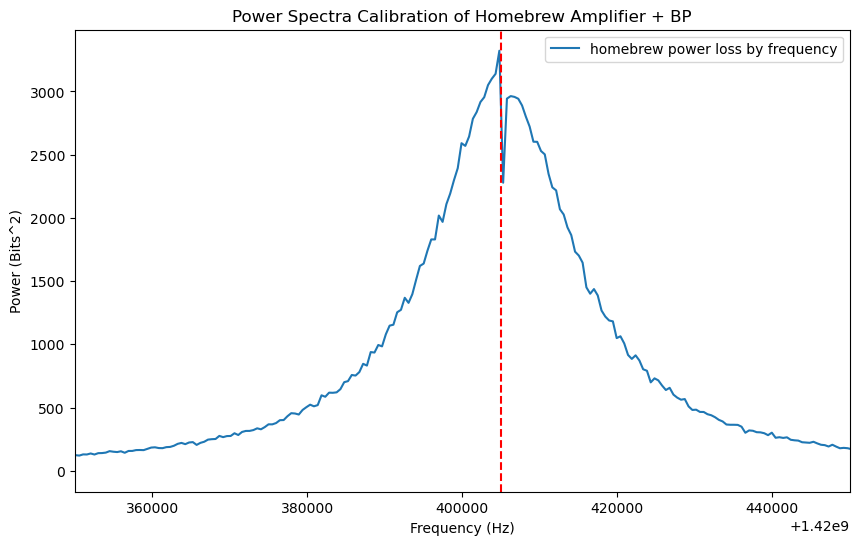

In [24]:
data_homebrew_on = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_homebrew_on.npz")
data_homebrew_off = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_homebrew_off.npz")

freqs_h_on, power_h_on = power_spectrum_average(data_homebrew_on)
freqs_h_off, power_h_off = power_spectrum_average(data_homebrew_off)

plt.figure(figsize = (10, 6))
# plt.plot(freqs_h_on, power_h_on, color="red", label = "homebrew amps on", alpha=0.7)
# plt.plot(freqs_h_off, power_h_off, label = "homebrew amps off", alpha=0.7)
# plt.yscale("log")
plt.xlim(1.42035e9, 1.42045e9)

r_h = power_h_off/power_h_on

plt.plot(freqs_h_on, r_h, label = "homebrew power loss by frequency")
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (Bits^2)")
plt.title("Power Spectra Calibration of Homebrew Amplifier + BP")
# print(10*np.log(max(power_h_on)), 10*np.log(max(power_h_off)), 10*np.log(max(r_h)))
plt.axvline(1420.405e6, color = "red", linestyle = "--")

(-50.0, 50.0)

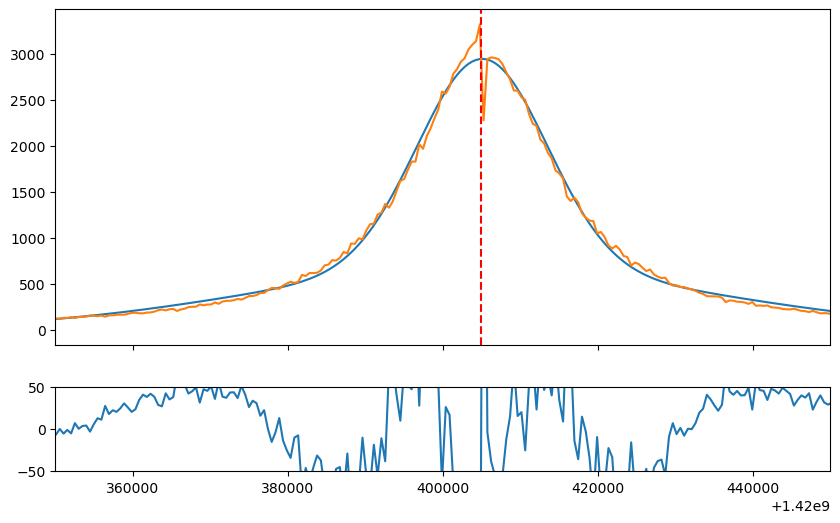

In [25]:
mask_bpf = (freqs_h_on < 1.420404e9) | (freqs_h_on > 1.420406e9)
guesses_bpf = {
    'amp': [500.0, 2800.0],  
    'avg': [1.420405e9, 1.420405e9], 
    'sig': [20000.0, 10000.0]   
}
# Fit using only the masked data
bpf_calibrated, cov_bpf = ugradio.gauss.gaussfit(freqs_h_on[mask_bpf], r_h[mask_bpf], **guesses_bpf, return_cov=True)
bpf_gauss = ugradio.gauss.gaussval(freqs_h_on, bpf_calibrated["amp"], bpf_calibrated["avg"], bpf_calibrated["sig"])

fig, ax = plt.subplots(2, 1, sharex=True, height_ratios = (4, 1), figsize=(10,6))
ax[0].plot(freqs_h_on, bpf_gauss)
ax[0].plot(freqs_h_on, r_h, label = "homebrew power loss by frequency")
ax[0].axvline(1420.405e6, color = "red", linestyle = "--")
ax[0].set_xlim(1.42035e9, 1.42045e9)
# print(bpf_calibrated)
# print(np.diag(cov_bpf))

ax[1].plot(freqs_h_on, bpf_gauss-r_h)
ax[1].set_ylim(-50, 50)

In [26]:
data_hamp_on = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_homebrew_amp_calib_on.npz")
data_hamp_off = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_homebrew_amp_calib_off.npz")

freqs_hamp_on, data_hamp_on = power_spectrum_average(data_homebrew_on)
freqs_hamp_off, data_hamp_off = power_spectrum_average(data_homebrew_off)

#### SDR voltage calibration

In [27]:
def dbm_to_volts(dbm, impedance=50.0):
    """
    Converts RF power in dBm to Voltage (RMS, Peak, and Peak-to-Peak).
    
    Parameters:
    dbm (float or np.ndarray): Power in dBm.
    impedance (float): System impedance in Ohms (default is 50 for RF systems).
    
    Returns:
    dict: A dictionary containing V_rms, V_peak, and V_peak_to_peak in Volts.
    """
    # 1. Convert dBm to linear Watts
    # (Divide by 10 to reverse the log, subtract 3 to go from mW to W)
    power_watts = 10 ** ((dbm - 30) / 10)
    
    # 2. Calculate RMS Voltage: P = V^2 / R  ->  V = sqrt(P * R)
    v_rms = np.sqrt(power_watts * impedance)
    
    # 3. Calculate Peak and Peak-to-Peak Voltages for a sine wave
    v_peak = v_rms * np.sqrt(2)
    v_peak_to_peak = v_peak * 2
    
    return {
        "V_rms": v_rms,
        "V_peak": v_peak,
        "V_pp": v_peak_to_peak
    }

def calculate_true_amplitude(data):
    """
    Calculates the averaged true digital amplitude of a sine wave
    using the I/Q magnitude method (Method 1).
    
    Parameters:
    data (dict): Dictionary containing "samples", a 3D array of shape (M, N, 2).
                 M = number of observations, N = samples per observation.
                 
    Returns:
    float: The final averaged digital amplitude for the entire dataset.
    """
    # 1. Extract I and Q and IMMEDIATELY convert to float to prevent int8 overflow!
    # data["samples"][:, :, 0] is the Real (I) and [:, :, 1] is the Imaginary (Q)
    I_data = (data["samples"][:, :, 0] * bits_to_volts / antenna_efficiency).astype(float)
    Q_data = (data["samples"][:, :, 1] * bits_to_volts / antenna_efficiency).astype(float)
    
    # 2. Calculate the instantaneous amplitude for every single point (M, N array)
    # using the Pythagorean theorem: A = sqrt(I^2 + Q^2)
    instantaneous_amplitudes = np.sqrt(I_data**2 + Q_data**2)
    
    # 3. Average over the N samples (axis=1) to get one true amplitude per observation
    # This reduces the array from shape (M, N) to (M,)
    mean_per_observation = np.mean(instantaneous_amplitudes, axis=1)
    
    # 4. Average across all M observations (axis=0) to get the final scalar value
    final_amplitude = np.mean(mean_per_observation, axis=0)
    
    # (Note: np.mean(instantaneous_amplitudes) does steps 3 and 4 simultaneously, 
    # but breaking it out like this matches your requested indexing logic!)
    
    return final_amplitude

In [28]:
# sdr_50 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-50dbm.npz")
# sdr_51 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-51dbm.npz")
# sdr_52 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-52dbm.npz")
# sdr_53 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-53dbm.npz")
# sdr_54 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-54dbm.npz")
# sdr_55 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-55dbm.npz")
# sdr_56 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-56dbm.npz")
# sdr_57 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-57dbm.npz")
# sdr_58 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-58dbm.npz")
# sdr_59 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-59dbm.npz")
# sdr_60 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-60dbm.npz")
# sdr_61 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-61dbm.npz")
# sdr_62 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-62dbm.npz")
# sdr_63 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-63dbm.npz")
# sdr_64 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-64dbm.npz")
# sdr_65 = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/sdr calibration/bighorn_sdr_calib_-65dbm.npz")

# freqs_sdr_50, power_sdr_50 = power_spectrum_average(sdr_50)
# freqs_sdr_51, power_sdr_51 = power_spectrum_average(sdr_51)
# freqs_sdr_52, power_sdr_52 = power_spectrum_average(sdr_52)
# freqs_sdr_53, power_sdr_53 = power_spectrum_average(sdr_53)
# freqs_sdr_54, power_sdr_54 = power_spectrum_average(sdr_54)
# freqs_sdr_55, power_sdr_55 = power_spectrum_average(sdr_55)
# freqs_sdr_56, power_sdr_56 = power_spectrum_average(sdr_56)
# freqs_sdr_57, power_sdr_57 = power_spectrum_average(sdr_57)
# freqs_sdr_58, power_sdr_58 = power_spectrum_average(sdr_58)
# freqs_sdr_59, power_sdr_59 = power_spectrum_average(sdr_59)
# freqs_sdr_60, power_sdr_60 = power_spectrum_average(sdr_60)
# freqs_sdr_61, power_sdr_61 = power_spectrum_average(sdr_61)
# freqs_sdr_62, power_sdr_62 = power_spectrum_average(sdr_62)
# freqs_sdr_63, power_sdr_63 = power_spectrum_average(sdr_63)
# freqs_sdr_64, power_sdr_64 = power_spectrum_average(sdr_64)
# freqs_sdr_65, power_sdr_65 = power_spectrum_average(sdr_65)

# # plt.figure(figsize = (10, 6))
# # plt.plot(freqs_sdr_40, power_sdr_40)
# # plt.plot(freqs_sdr_45, power_sdr_45)
# # plt.plot(freqs_sdr_50, power_sdr_50)
# # plt.plot(freqs_sdr_55, power_sdr_55)
# # plt.yscale("log")

In [29]:
# sdr_bits = []
# sdr_volts = []
# for i in range(51, 65):
#     var_name = f"sdr_{i}"
#     current_sdr = globals()[var_name]
#     sdr_bits.append(calculate_true_amplitude(current_sdr))
#     sdr_volts.append(dbm_to_volts(-i)["V_peak"])

# sdr_coeffs, sdr_cov = np.polyfit(sdr_bits, sdr_volts, 1, cov = True)

# fig, ax = plt.subplots(2, 1, sharex=True, height_ratios = (4, 2), figsize=(8,4))
# ax[0].errorbar(sdr_bits, np.array(sdr_volts)*100, yerr=(sdr_coeffs[0]*4*100), fmt="o", ms=4, capsize=2.5, label = "Recieved SDR data at 45dB Gain", color = "red")
# ax[0].plot(range(0, 128), np.polyval(sdr_coeffs, range(0, 128))*100, label = "Least Squares Fit", color = "green", linestyle = "--")
# ax[0].legend()
# ax[0].set_ylabel("Voltage (mV)")
# ax[0].set_xlim(0, 127)
# ax[0].set_xticks([0, 16, 32, 48, 64, 80, 96, 112, 128])

# ax[1].scatter(sdr_bits, (sdr_volts - np.polyval(sdr_coeffs, sdr_bits))*100, label="Residuals", color = "red", s = 10)
# ax[1].set_xlabel("Voltage (Bits)")
# ax[1].set_ylabel("Residuals (mV)")
# ax[1].set_ylim(-1.5e-3, 1.5e-3)
# ax[1].set_xticks([0, 16, 32, 48, 64, 80, 96, 112, 128])
# ax[1].axhline(0, color = "blue", linestyle = "--")

# ax[0].set_title("SDR Bits to Voltage Linear Least Squares Fit")

# print(sdr_coeffs)

In [30]:
hamp_on_amp = calculate_true_amplitude(data_homebrew_on)
hamp_off_amp = calculate_true_amplitude(data_homebrew_off)

print(hamp_on_amp, hamp_off_amp, hamp_off_amp/hamp_on_amp)

2.656627515479319 110.96852909396362 41.77045086199909


### power loss in cable

In [31]:
data_cable_known = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/known_cable_length_500kHz_45dB.npz")
data_cable_tele = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/scope_cable_length_500kHz_45dB.npz")

print(calculate_true_amplitude(data_cable_known), calculate_true_amplitude(data_cable_tele), calculate_true_amplitude(data_cable_tele)/calculate_true_amplitude(data_cable_known))

8.415184761632878 5.397135030417932 0.6413566883314247


## perseus arm

In [32]:
data_perseus_on = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_120_0_on.npz")
data_perseus_off = np.load("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/bighorn_cyg_x_off_2MHz.npz")

G_continuum = 26.8 + 26.8 + 26.8 - 2.2 - 15.31 + 45 + 41.77
print(G_continuum)

149.66


In [33]:
freq_pon, power_pon = power_spectrum_average(data_perseus_on, method = "mean")
freq_poff, power_poff = power_spectrum_average(data_perseus_off, method = "mean")

power_pon_smoothed, outliers_pon, rolling_pon = robust_clean_and_smooth(power_pon)
power_poff_smoothed, outliers_poff, rolling_poff = robust_clean_and_smooth(power_poff)

r_p = power_pon / power_poff
r_p_smooth = power_pon_smoothed / power_poff_smoothed
r_p_rolling = rolling_pon / rolling_poff

T_p = r_p_rolling * G_continuum

freq_p_peak, power_p_peak, idx_p_peak = find_hi_peak(freq_pon, T_p)

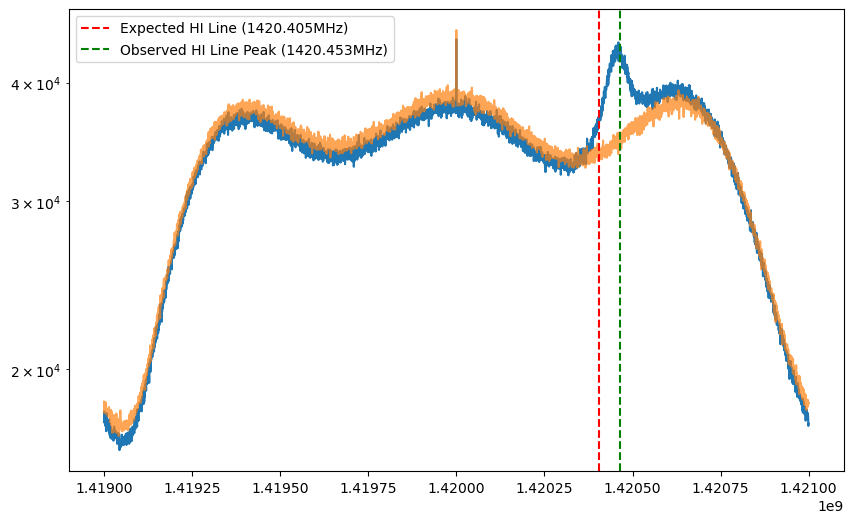

In [34]:
plt.figure(figsize = (10, 6))

plt.plot(freq_pon, power_pon)
plt.plot(freq_poff, power_poff, alpha = 0.7)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_p_peak/1e6:.7}MHz)")
plt.legend()
plt.yscale("log")

[False False False ... False False False]


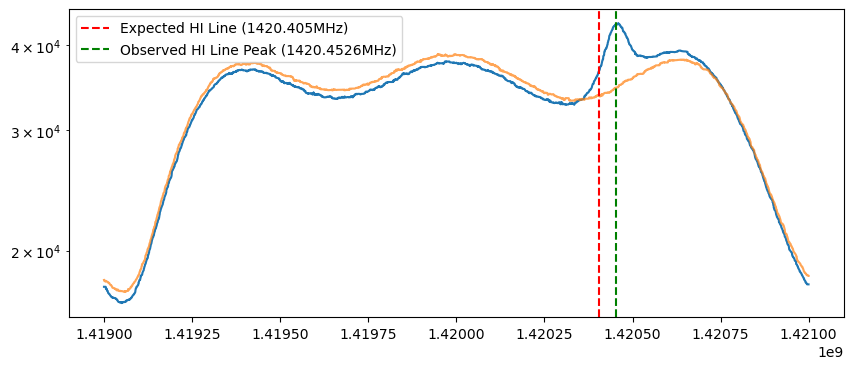

In [35]:
print(outliers_son)
plt.figure(figsize = (10, 4))
plt.plot(freq_pon, rolling_pon)
plt.plot(freq_poff, rolling_poff, alpha = 0.7)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_p_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_p_peak/1e6:.8}MHz)")
plt.yscale("log")
plt.legend()
# plt.xlim(1.42045e9, 1.42060e9)

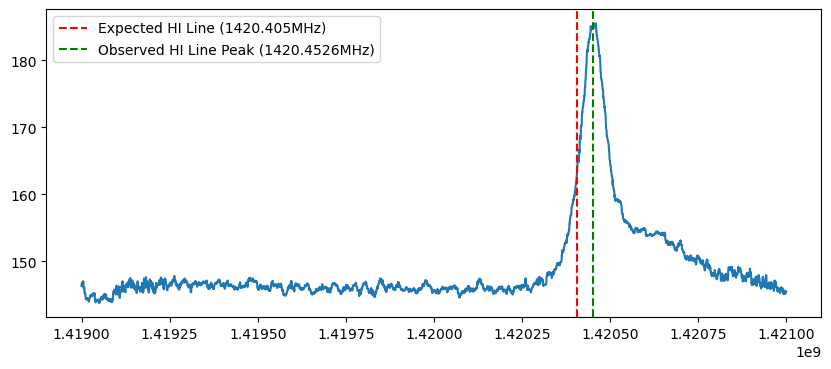

In [36]:
plt.figure(figsize=(10, 4))
# plt.plot(freq_son, r)
# plt.plot(freq_son, r_smooth)
plt.plot(freq_pon, T_p)
# plt.ylim(0.9, 1.4)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_p_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_p_peak/1e6:.8}MHz)")
plt.legend()
plt.show()

2.02676213765871


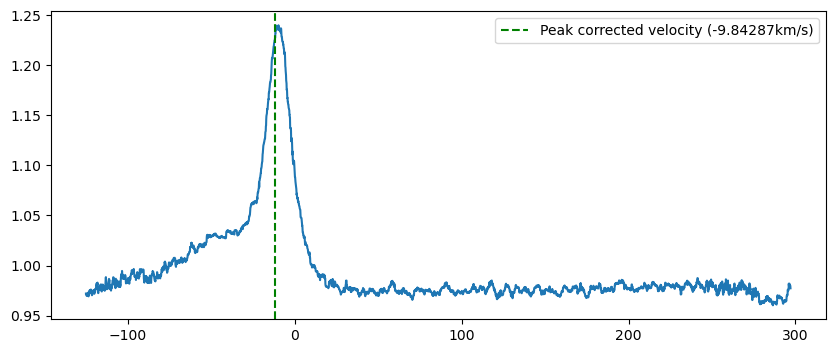

In [37]:
velocity_profile_p = velocity(freq_pon)

v_p_peak, v_p_max, v_p_idx = find_hi_peak(velocity_profile, T_p)

plt.figure(figsize = (10, 4))
plt.plot(velocity_profile_p / 1000, r_p_rolling) #change to T_pon when we finalize gain calibration
plt.axvline(v_peak / 1000, color = "green", linestyle = "--", label=f"Peak corrected velocity ({v_p_peak/1000:.6}km/s)")
plt.legend()

print(calculate_lsr_correction(data_perseus_on) / 1000)

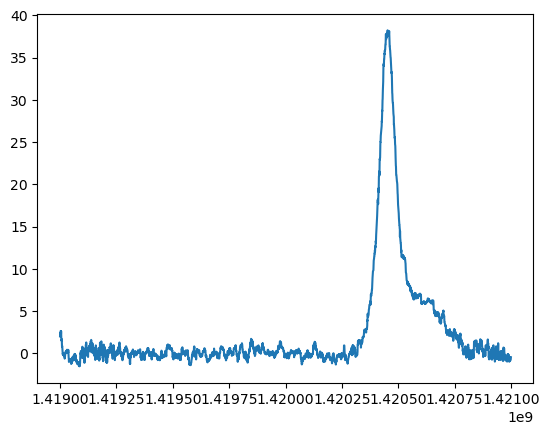

In [38]:
# 1. Find the center point of your frequencies
freq_center = np.mean(freq_pon)

# 2. Subtract that center from your x-data to make the numbers small
x_shifted = freq_pon - freq_center

# 3. Now perform the fit using the SHIFTED x-data
degree = 4
mask_off = (freq_pon < 1.42025e9) | (freq_pon > 1.42085e9)

coeffs, cov_poly = np.polyfit(x_shifted[mask_off], T_p[mask_off], degree, cov=True)

# 4. Evaluate the baseline (IMPORTANT: you must evaluate using the shifted data too!)
fitted_baseline = np.polyval(coeffs, x_shifted)

# 5. Subtract as normal
T_p_baseline = T_p - fitted_baseline

plt.plot(freq_pon, T_p - fitted_baseline, label = "HI Line")
# plt.plot(freq_pon/1e9, fitted_baseline, label = "Fitted function for HI Line")

X_design = np.vander(x_shifted, degree + 1)
var_baseline = np.sum((X_design @ cov_poly) * X_design, axis=1)
err_baseline = np.sqrt(var_baseline)

In [39]:
mask_on = (freqs_h_on > 1.42025e9) | (freqs_h_on < 1.42085e9)
guesses_T_p = {
    'amp': [40, 10],  
    'avg': [1.420452e9, 1.42055e9], 
    'sig': [20000.0, 10000.0]   
}
# Fit using only the masked data
T_p_calibrated, cov_g = ugradio.gauss.gaussfit(freqs_h_on[mask_on], T_p_baseline[mask_on], **guesses_T_p, return_cov=True)
T_p_gauss = ugradio.gauss.gaussval(freqs_h_on, T_p_calibrated["amp"], T_p_calibrated["avg"], T_p_calibrated["sig"])
T_p_residuals = T_p - (T_p_gauss + fitted_baseline)

# mask_on = (freqs_h_on > 1.42025e9) | (freqs_h_on < 1.42085e9)
# guesses_T_p = {
#     'amp': [185, 140, 150],  
#     'avg': [1.420452e9, 1.42055e9, 1.42090e9], 
#     'sig': [20000.0, 10000.0, 10000.0]   
# }
# # Fit using only the masked data
# T_p_calibrated, cov_g = ugradio.gauss.gaussfit(freqs_h_on[mask_on], T_p_baseline[mask_on], **guesses_T_p, return_cov=True)
# T_p_gauss = ugradio.gauss.gaussval(freqs_h_on, T_p_calibrated["amp"], T_p_calibrated["avg"], T_p_calibrated["sig"])

# plt.plot(freq_pon/1e9, T_p_baseline)

[4.07625390e-50 1.03174671e-38 3.19872370e-26 7.27966681e-15
 3.17492109e-04] [8.28332648e-03 7.95517204e+03 1.32701276e+04 2.50811629e-03
 1.42571552e+06 5.97024575e+05]
0.3662879621574104


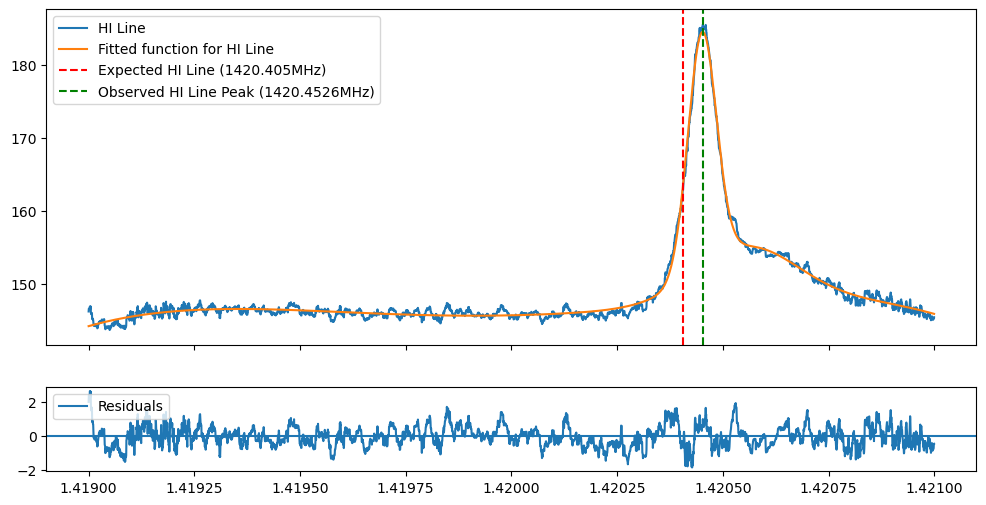

In [40]:
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios = (4, 1), figsize=(12,6))
ax[0].plot(freq_pon/1e9, T_p, label = "HI Line")
ax[0].plot(freq_pon/1e9, T_p_gauss + fitted_baseline, label = "Fitted function for HI Line")
ax[0].axvline(1420.405e-3, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
ax[0].axvline(freq_p_peak/1e9, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_p_peak/1e6:.8}MHz)")
# ax[0].plot(freq_pon/1e9, fitted_baseline + ugradio.gauss.gaussval(freq_pon, T_p_calibrated["amp"][0], T_p_calibrated["avg"][0], T_p_calibrated["sig"][0]))
# ax[0].plot(freq_pon/1e9, fitted_baseline + ugradio.gauss.gaussval(freq_pon, T_p_calibrated["amp"][1], T_p_calibrated["avg"][1], T_p_calibrated["sig"][1]))
ax[0].legend()

ax[1].plot(freqs_h_on/1e9, T_p_residuals, label="Residuals")
ax[1].axhline(0)
ax[1].legend(loc="upper left")

# print(np.diag(cov_g))
print(np.diag(cov_poly), np.diag(cov_g))

print(np.sum(T_p_residuals**2) / len(T_p_residuals))

In [41]:
# Physical Constants
c_kms = 299792.458  # Speed of light in km/s
nu_0 = 1420.40575177e6  # Rest frequency of HI in Hz

# Extract Gaussian parameters into a single 1D array for the MC sampler
# Order: [amp1, avg1, sig1, amp2, avg2, sig2]
gauss_popt = np.array([
    T_p_calibrated['amp'][0], T_p_calibrated['avg'][0], T_p_calibrated['sig'][0],
    T_p_calibrated['amp'][1], T_p_calibrated['avg'][1], T_p_calibrated['sig'][1]
])

# --- Statistical Error on Parameters ---
# For the Gaussians
gauss_errors_formal = np.sqrt(np.diag(cov_g))

# For the Polynomial
poly_errors_formal = np.sqrt(np.diag(cov_poly))

print("--- Method 1: Formal Covariance Errors ---")
print(f"Gaussian 1 Amp Error: {gauss_errors_formal[0]:.4f} K")
print(f"Gaussian 1 Center Error: {gauss_errors_formal[1]:.2f} Hz")
print(f"Gaussian 1 Width Error: {gauss_errors_formal[2]:.2f} Hz")
print(f"Gaussian 2 Amp Error: {gauss_errors_formal[3]:.4f} K")
print(f"Gaussian 2 Center Error: {gauss_errors_formal[4]:.2f} Hz")
print(f"Gaussian 2 Width Error: {gauss_errors_formal[5]:.2f} Hz")
print(f"Polyfit: x^4: {poly_errors_formal[0]}")
print(f"Polyfit: x^3: {poly_errors_formal[1]}")
print(f"Polyfit: x^2: {poly_errors_formal[2]}")
print(f"Polyfit: x^1: {poly_errors_formal[3]}")
print(f"Polyfit: x^0: {poly_errors_formal[4]}")

--- Method 1: Formal Covariance Errors ---
Gaussian 1 Amp Error: 0.0910 K
Gaussian 1 Center Error: 89.19 Hz
Gaussian 1 Width Error: 115.20 Hz
Gaussian 2 Amp Error: 0.0501 K
Gaussian 2 Center Error: 1194.03 Hz
Gaussian 2 Width Error: 772.67 Hz
Polyfit: x^4: 2.0189734764552244e-25
Polyfit: x^3: 1.0157493328467537e-19
Polyfit: x^2: 1.7884976101185329e-13
Polyfit: x^1: 8.53209634694715e-08
Polyfit: x^0: 0.017818308245860476


In [42]:
num_samples = 1000

# Draw samples for both
mc_poly = np.random.multivariate_normal(coeffs, cov_poly, num_samples)
mc_gauss = np.random.multivariate_normal(gauss_popt, cov_g, num_samples)

# Calculate the standard deviation of the samples to get parameter errors
gauss_errors_mc = np.std(mc_gauss, axis=0)
poly_errors_mc = np.std(mc_poly, axis=0)

print("\n--- Method 2: Monte Carlo Parameter Errors ---")
print(f"Gaussian 1 Amp Error: {gauss_errors_mc[0]:.4f} K")
print(f"Gaussian 1 Center Error: {gauss_errors_mc[1]:.2f} Hz")
print(f"Gaussian 1 Width Error: {gauss_errors_mc[2]:.2f} Hz")
print(f"Gaussian 2 Amp Error: {gauss_errors_mc[3]:.4f} K")
print(f"Gaussian 2 Center Error: {gauss_errors_mc[4]:.2f} Hz")
print(f"Gaussian 2 Width Error: {gauss_errors_mc[5]:.2f} Hz")
print(f"Polyfit: x^4: {poly_errors_mc[0]}")
print(f"Polyfit: x^3: {poly_errors_mc[1]}")
print(f"Polyfit: x^2: {poly_errors_mc[2]}")
print(f"Polyfit: x^1: {poly_errors_mc[3]}")
print(f"Polyfit: x^0: {poly_errors_mc[4]}")


# --- Generate the Error Band for the Plot ---
all_curves = np.zeros((num_samples, len(freq_pon)))
for i in range(num_samples):
    y_p = np.polyval(mc_poly[i], x_shifted)
    p = mc_gauss[i]
    y_g = ugradio.gauss.gaussval(freq_pon, p[0::3], p[1::3], p[2::3])
    all_curves[i, :] = y_p + y_g

# This is the 'sigma' for your fill_between plot
total_curve_sigma = np.std(all_curves, axis=0)


--- Method 2: Monte Carlo Parameter Errors ---
Gaussian 1 Amp Error: 0.0934 K
Gaussian 1 Center Error: 87.85 Hz
Gaussian 1 Width Error: 115.48 Hz
Gaussian 2 Amp Error: 0.0517 K
Gaussian 2 Center Error: 1178.72 Hz
Gaussian 2 Width Error: 770.21 Hz
Polyfit: x^4: 1.0445162651480578e-23
Polyfit: x^3: 8.402834872652688e-16
Polyfit: x^2: 1.7696538204830397e-13
Polyfit: x^1: 8.448161895026108e-08
Polyfit: x^0: 0.017091357311629276


In [43]:
# 1. Estimate noise floor (sigma_thermal) 
# Use a region of the residuals where there is no signal
noise_region = T_p_residuals[(freq_pon < 1.4202e9) | (freq_pon > 1.4209e9)]
sigma_thermal = np.std(noise_region)

# 2. Calculate Chi-Square
# chi2 = sum( (data - model)^2 / error^2 )
chi2 = np.sum((T_p_residuals / sigma_thermal)**2)

# 3. Reduced Chi-Square
# DOF = N_points - N_parameters (5 poly + 6 gauss = 11)
dof = len(T_p_residuals) - 11
red_chi2 = chi2 / dof

print(f"\nThermal Noise Level: {sigma_thermal:.4f} K")
print(f"Reduced Chi-Square: {red_chi2:.4f}")

if red_chi2 > 1.5:
    print("Warning: chi_r^2 is high. Consider adding a 3rd Gaussian or checking systematics.")


Thermal Noise Level: 0.5549 K
Reduced Chi-Square: 1.1927


### antenna efficiency

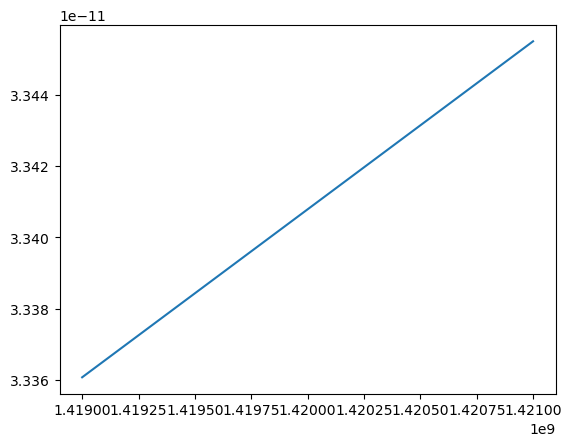

In [44]:
def power_ideal(nu, Tb = 295, A = 0.76903072, Omega = 1.22**2, B = 160e6, kb=1.38e-23, c=3e8):
    I = 2 * kb * Tb * nu**2 / c**2 
    P = I * A * Omega * B
    return P
P_noise = 1.38e-23 * 295 * 160e6
plt.plot(freq_pon, power_ideal(freq_pon))

### making sim data

In [45]:
def generate_hi_simulation():
    # --- Configuration ---
    N = 250000              # Number of datapoints
    fs = 5e9               # Sample rate: 3 GHz
    freq_hi = 1.420e9        # HI Line frequency: 1420 MHz
    
    # Physics Parameters
    T_rcvr = 70.0            # Receiver Temp (K)
    T_sky = 10.0             # Continuum Sky Temp (K)
    T_cont = T_rcvr + T_sky  # Total Continuum (80 K)
    T_peak_hi = 30.0         # HI Line Peak (K)
    
    # Define Frequency Axis (0 to Nyquist)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    
    # --- 1. Construct Temperature Profile T_sys(nu) ---
    # Top Panel: The true temperature of the sky+receiver
    # Constant continuum
    T_sys_spectrum = np.full_like(freqs, T_cont)

    # --- 4. Generate Time-Series Data ---
    # Generate random complex noise
    real_part = np.random.randn(len(freqs))
    imag_part = np.random.randn(len(freqs))
    white_noise = (real_part + 1j * imag_part) * 4

    # Peak 1: The Main HI Line (Cold Neutral Medium)
    freq_1 = 1.420405e9
    width_1 = 0.12e6  # Narrow
    amp_1 = 56    # Strong
    signal_1 = amp_1 * np.exp(-0.5 * ((freqs - freq_1) / width_1)**2)
    
    # Peak 2: The Second Component (e.g., Warm Medium or Cloud)
    # Offset by -1.2 MHz, Broader, Weaker
    freq_2 = 1.420e9
    width_2 = 0.09e6  # Broad
    amp_2 = 24     # Weaker (relative amplitude 0.5)
    signal_2 = amp_2 * np.exp(-0.5 * ((freqs - freq_2) / width_2)**2)
    
    # Combine
    T_sys_spectrum += signal_1 + signal_2 + white_noise.real
    
    # --- 2. Construct System Gain G(nu) (Systematics) ---
    # Second Panel: The Gain
    # REQUESTED CHANGE: Flat Top with 2 MHz bandwidth
    # 2 MHz width centered at 1420 MHz
    
    # Define the flat top mask
    # We use a super-gaussian order to make edges sharp but continuous
    bw = 2.5e6
    order = 8 # Controls "squareness"
    # Normalized frequency offset
    x = (freqs - freq_hi) / (bw / 2)
    G_flat = np.exp(-(x**order))
    
    # Add "Wiggles" (Impedance mismatch ripple)
    # 5% ripple
    G_ripple = 1.0 + 0.05 * np.cos(2 * np.pi * freqs / (bw/8))
    # Total Gain
    # We set a baseline of 1e-4 so we don't divide by zero outside the band
    G_total = G_flat * G_ripple
    G_total[G_total < 1e-4] = 1e-4
    G_total = G_total/np.linalg.norm(G_total)
    
    # --- 3. Generate Measurement Power P(nu) ---
    # Third Panel: Observed Power (Gain * T_sys)
    power_spectrum_expected = G_total * T_sys_spectrum
    
    # Scale by amplitude (sqrt of power)
    shaped_noise_freq = white_noise * np.sqrt(power_spectrum_expected) * np.sqrt(N/2)
    
    # Fix DC and Nyquist
    shaped_noise_freq[0] = shaped_noise_freq[0].real
    if N % 2 == 0:
        shaped_noise_freq[-1] = shaped_noise_freq[-1].real
        
    # IFFT to get time series
    voltage_data = np.fft.irfft(shaped_noise_freq, n=N)
    
    return voltage_data, freqs, T_sys_spectrum, G_total, power_spectrum_expected, white_noise

def get_ideal_sky_timeseries(N, T_sys_spectrum, specific_noise=None):
    """
    Generates the time-domain voltage signal of the 'First Plot' 
    (The sky + receiver noise, BEFORE the Gain filter is applied).
    
    Parameters:
    - N: Number of points (e.g., 250000)
    - T_sys_spectrum: The power spectrum array (from Step 1 of your code)
    - specific_noise: (Optional) The complex white noise array used in the main 
                      simulation. If provided, the time series will match the 
                      randomness of your main simulation exactly.
    """
    
    # 1. Handle the White Noise
    if specific_noise is None:
        # Generate fresh noise if none provided
        real_part = np.random.randn(len(T_sys_spectrum))
        imag_part = np.random.randn(len(T_sys_spectrum))
        # Matches your scaling of * 4
        white_noise = (real_part + 1j * imag_part) * 4 
    else:
        white_noise = specific_noise

    # 2. Shape the noise by the Ideal T_sys Spectrum (Scanning G=1)
    # We take the sqrt because T_sys is Power, and we need Voltage for FFT
    # Note: We use absolute value to ensure no issues if your added noise 
    # dipped T_sys slightly negative (unlikely but safer).
    shaped_noise_ideal = white_noise * np.sqrt(np.abs(T_sys_spectrum)) * np.sqrt(N/2)

    # 3. Enforce Real-Valued Time Series constraints
    shaped_noise_ideal[0] = shaped_noise_ideal[0].real
    if N % 2 == 0:
        shaped_noise_ideal[-1] = shaped_noise_ideal[-1].real
        
    # 4. Inverse FFT to get Time-Series Voltage
    voltage_ideal = np.fft.irfft(shaped_noise_ideal, n=N)
    
    return voltage_ideal

(1418.0, 1422.0)

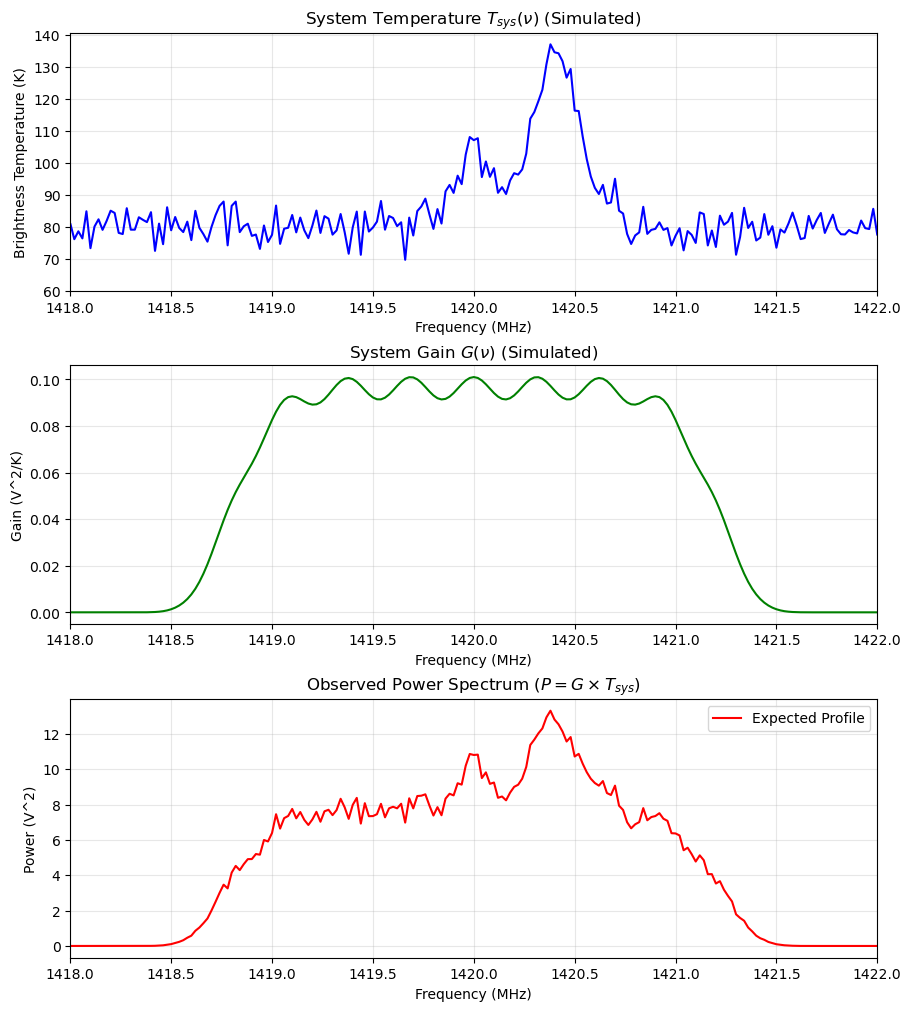

In [46]:
# --- Run Simulation ---
voltage_data, freqs, T_sys, Gain, Power_Expected, white_noise = generate_hi_simulation()

# --- Plotting (Mimicking the 4 Panels) ---
fig, axs = plt.subplots(nrows=3, figsize=(9, 10), constrained_layout=True)

# Panel 1: T_sys (Model)
axs[0].plot(freqs/1e6, T_sys, color='blue', lw=1.5)
axs[0].set_title(r"System Temperature $T_{sys}(\nu)$ (Simulated)")
axs[0].set_xlabel("Frequency (MHz)")
axs[0].set_ylabel("Brightness Temperature (K)")
axs[0].grid(True, alpha=0.3)
axs[0].set_xlim(1418, 1422) # Zoom in to see the line

# Panel 2: Gain (Flat Top)
axs[1].plot(freqs/1e6, Gain, color='green', lw=1.5)
axs[1].set_title(r"System Gain $G(\nu)$ (Simulated)")
axs[1].set_xlabel("Frequency (MHz)")
axs[1].set_ylabel("Gain (V^2/K)")
axs[1].grid(True, alpha=0.3)
axs[1].set_xlim(1418, 1422)

# Panel 3: Observed Power (Gain * T_sys)
# Calculate FFT of the noisy time series to show "Real" data
fft_measured = np.abs(np.fft.rfft(voltage_data))**2
# plt.plot(freqs/1e6, fft_measured, color='gray', alpha=0.5, label='Measured Snapshot')
axs[2].plot(freqs/1e6, Power_Expected, color='red', lw=1.5, label='Expected Profile')
axs[2].set_title(r"Observed Power Spectrum ($P = G \times T_{sys}$)")
axs[2].set_xlabel("Frequency (MHz)")
axs[2].set_ylabel("Power (V^2)")
axs[2].legend()
axs[2].grid(True, alpha=0.3)
axs[2].set_xlim(1418, 1422)

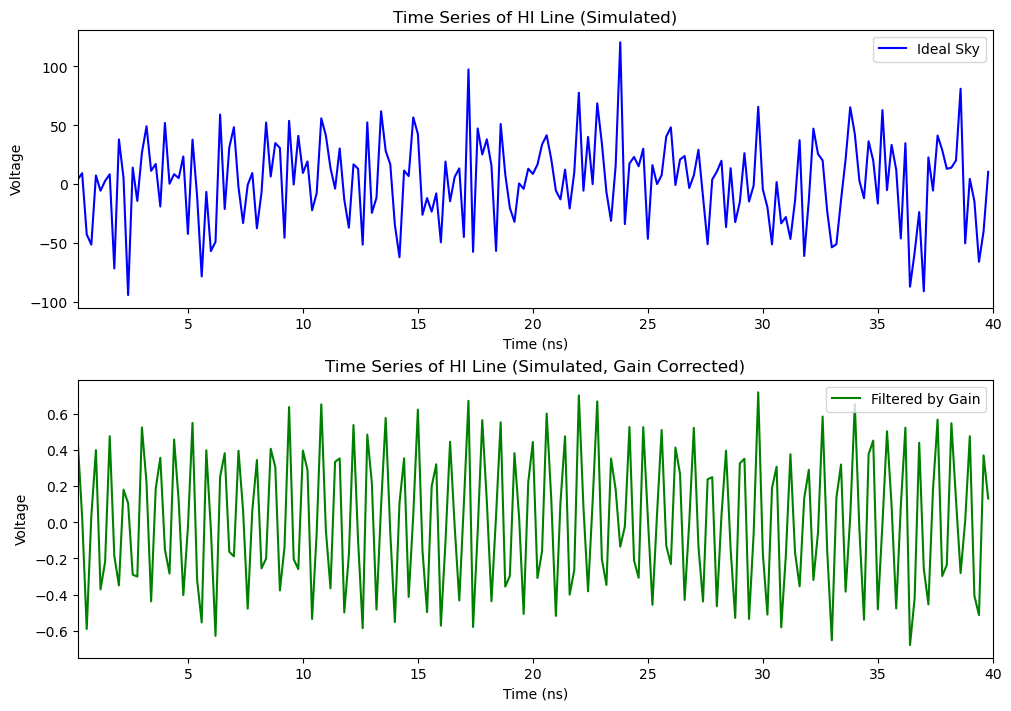

In [47]:
voltage_ideal_sky = get_ideal_sky_timeseries(len(voltage_data), T_sys, specific_noise=white_noise)

fig, axs = plt.subplots(nrows=2, figsize=(10, 7), constrained_layout=True)
axs[0].plot(np.array(np.arange(125001) / 5)[1:200], voltage_ideal_sky[1:200], color = "blue", label="Ideal Sky")
axs[0].set_title("Time Series of HI Line (Simulated)")
axs[0].set_xlabel("Time (ns)")
axs[0].set_ylabel("Voltage")
axs[0].set_xlim(np.array(np.arange(125001) / 5)[1], (np.array(np.arange(125001) / 5)[200]))
axs[0].legend(loc="upper right")

axs[1].plot(np.array(np.arange(125001) / 5)[1:200], voltage_data[1:200], color = "green", label="Filtered by Gain")
axs[1].set_title("Time Series of HI Line (Simulated, Gain Corrected)")
axs[1].set_xlabel("Time (ns)")
axs[1].set_ylabel("Voltage")
axs[1].set_xlim(np.array(np.arange(125001) / 5)[1], (np.array(np.arange(125001) / 5)[200]))
axs[1].legend(loc="upper right")


In [48]:
print(voltage_ideal_sky.shape,
voltage_measured.shape,
T_sys.shape,
Gain.shape,
Power_Expected.shape)

NameError: name 'voltage_measured' is not defined

In [ ]:
data = pd.DataFrame({
                    "time (ns)": np.array(np.arange(125001) / 5e9),
                    "time series": voltage_ideal_sky[:125001],
                    "time series, gain corrected": voltage_measured[:125001],
                    "frequencies": freqs,
                    "HI voltage spectrum": T_sys,
                    "gain pattern": Gain,
                    "HI voltage spectrum, gain corrected": Power_Expected
                    })

display(data)
# data.to_hdf("/global/homes/e/ewille/26Sp_Astro_121/Lab_2/wille_simulated_data.h5", key="data")